In [1]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

In [2]:
import json
import numpy as np

n_nodes = "all"

traj = 5

if traj == 1:
    file_path = "strip_data/strip_test1_22pts_v15.json"
    drop_first_points = 3
    expected_points = 22 - drop_first_points
    output_path = f"n7_traj1_strip_dataset_{expected_points}_pts.npz"

elif traj == 2:
    file_path = "strip_data/strip_test2_16pts_v2.json"
    drop_first_points = 2
    expected_points = 16 - drop_first_points
    output_path = f"n7_traj2_strip_dataset_{expected_points}_pts.npz"

elif traj == 3:
    file_path = "strip_data/strip_test3_16pts_v2.json"
    drop_first_points = 2
    expected_points = 16 - drop_first_points
    output_path = f"n7_traj3_strip_dataset_{expected_points}_pts.npz"

elif traj == 4:
    file_path = "strip_data/strip_test4_30pts_v2.json"
    drop_first_points = 2
    expected_points = 30 - drop_first_points
    output_path = f"n7_traj4_strip_dataset_{expected_points}_pts.npz"

elif traj == 5:
    file_path = "strip_data/strip_test5_30pts_v1.json"
    drop_first_points = 1
    expected_points = 30 - drop_first_points
    output_path = f"n7_traj5_strip_dataset_{expected_points}_pts.npz"

elif traj == 6:
    file_path = "strip_data/strip_test6_23pts_v1.json"
    drop_first_points = 2
    expected_points = 23 - drop_first_points
    output_path = f"n7_traj6_strip_dataset_{expected_points}_pts.npz"

elif traj == 7:
    file_path = "strip_data/strip_test7_23pts_v1.json"
    drop_first_points = 2
    expected_points = 23 - drop_first_points
    output_path = f"n7_traj7_strip_dataset_{expected_points}_pts.npz"

# elif traj == 8:
#     file_path = "strip_data/strip_test8_20pts_v1.json"
#     output_path = "n7_traj8_strip_dataset_20_pts.npz"

Loaded 30 samples
Persistent markers kept: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_4', 'marker_5', 'marker_6']
Fixed marker used for origin: marker_6
Markers used in state: ['marker_5', 'marker_4', 'marker_3', 'marker_2', 'marker_1']
Final node = marker_0 (no end-effector used in state/BCs)


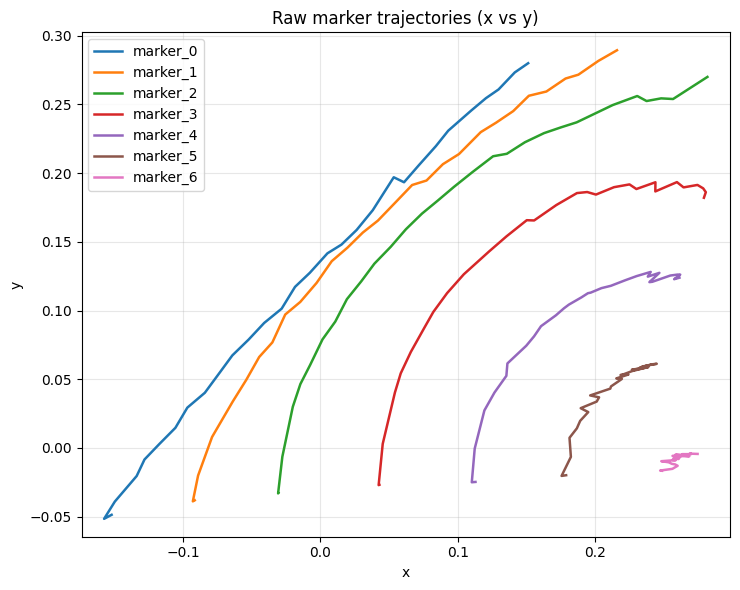

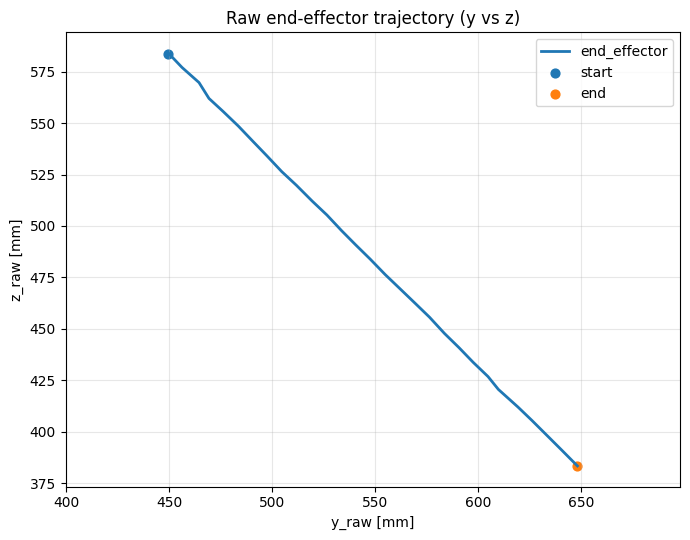

Origin from fixed marker mean:
x0 = 0.26023803416361363
y0 = -0.007897062622461268
z0 = 0.7768717068003335


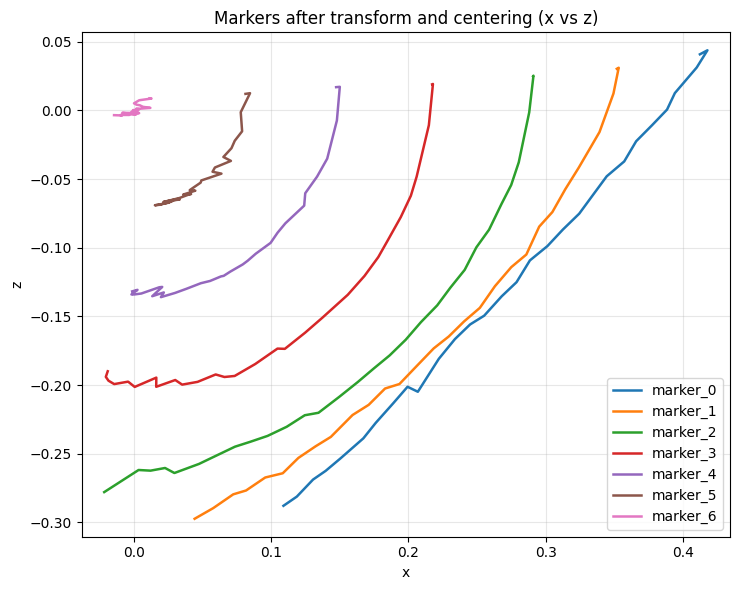

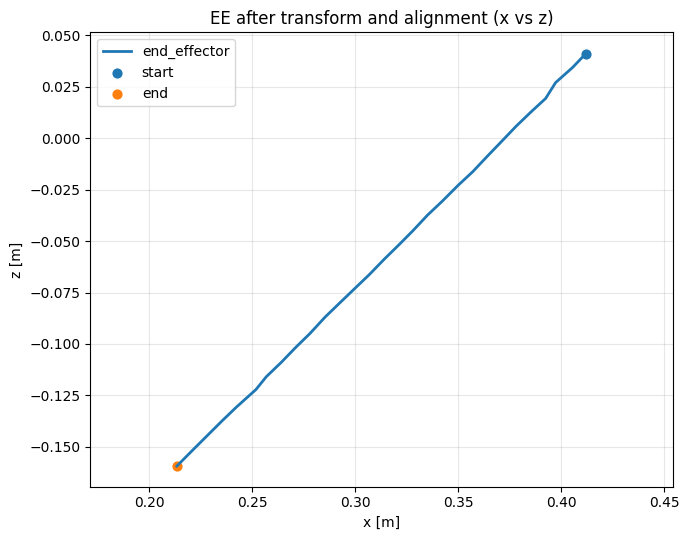

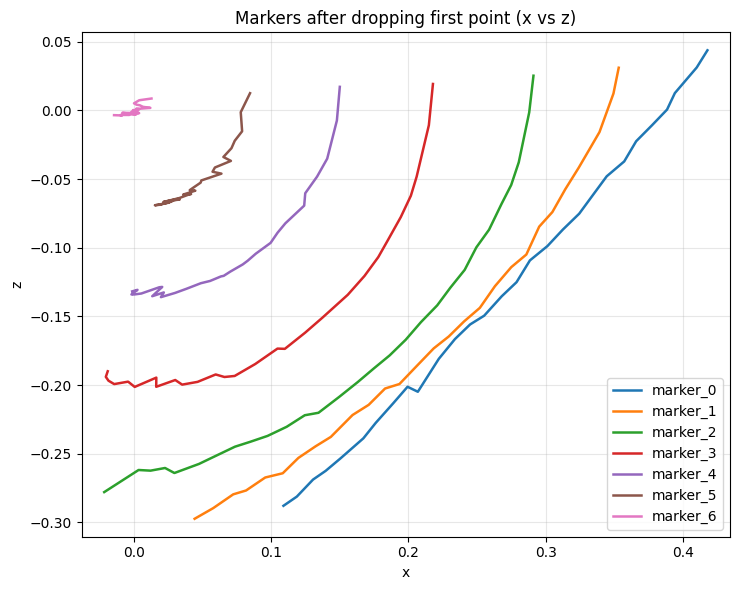

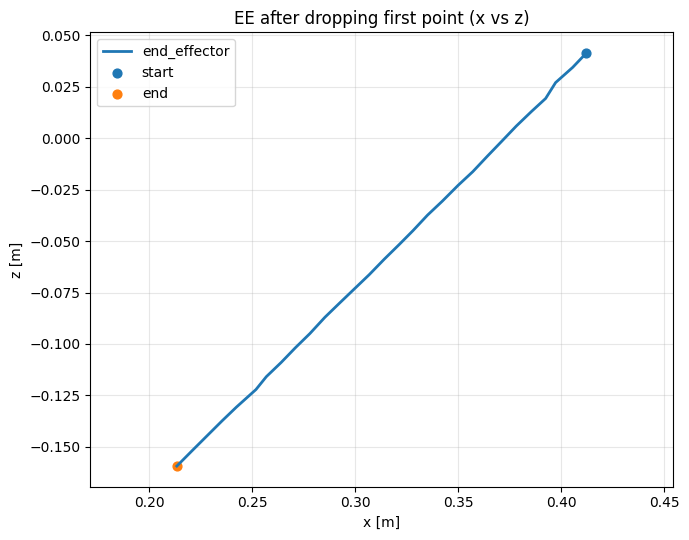

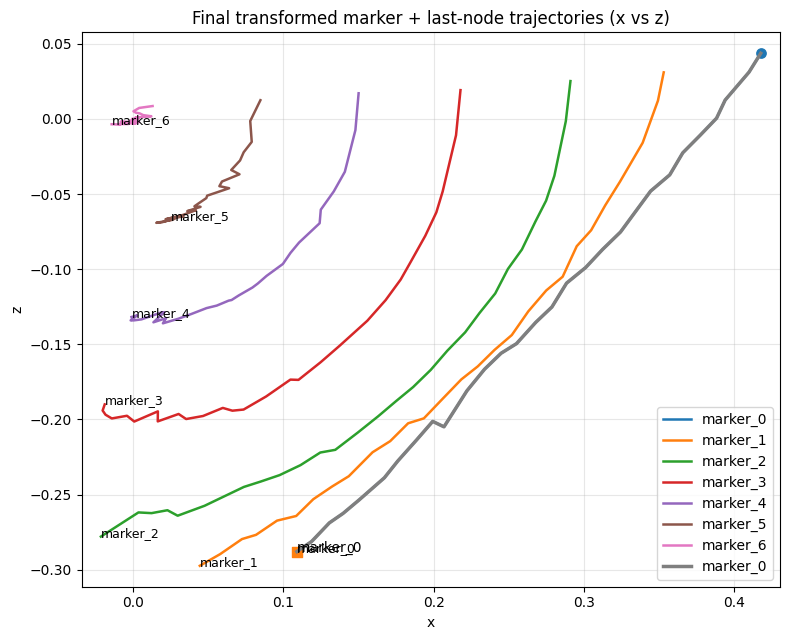

Removing NaNs: kept 29/29 timesteps
Right ghost edge length from frame 0 (marker_0 to marker_1): 0.06581998956083215
target_n_nodes: 9
use_ee_as_last_node: False
prepend_clamped_node_flag: True
append_right_ghost_clamp_flag: True
min_marker_presence_ratio: 0.8
qs shape: (1, 29, 35)
xb shape: (1, 29, 20)
idx_b: [ 0  1  2  3  4  5  6  7 11 15 19 23 27 28 29 30 31 32 33 34]
lambdas shape: (1, 29)


In [ ]:
from extract_data import extract_directbc_dataset, plot_qs_snapshots
qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_points=drop_first_points, n_nodes=n_nodes, use_ee_as_last_node=False, prepend_clamped_node_flag=True, append_right_ghost_clamp_flag=True)

In [4]:
print(qs[0,0,:])

[0.         0.         0.         0.         0.08559755 0.
 0.         0.         0.17028055 0.         0.01247915 0.
 0.23562872 0.         0.01710089 0.         0.30342612 0.
 0.01918964 0.         0.3766055  0.         0.02521278 0.
 0.43867029 0.         0.03100829 0.         0.50325377 0.
 0.04370656 0.         0.56907376 0.         0.04370656]


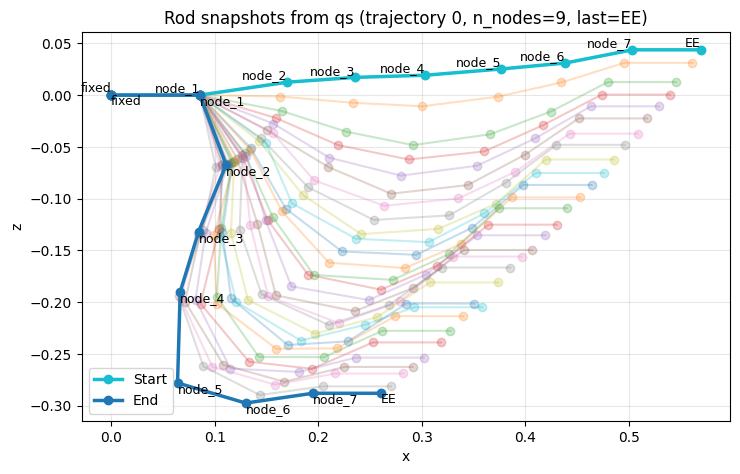

In [5]:
plot_qs_snapshots(qs, every_step=1)

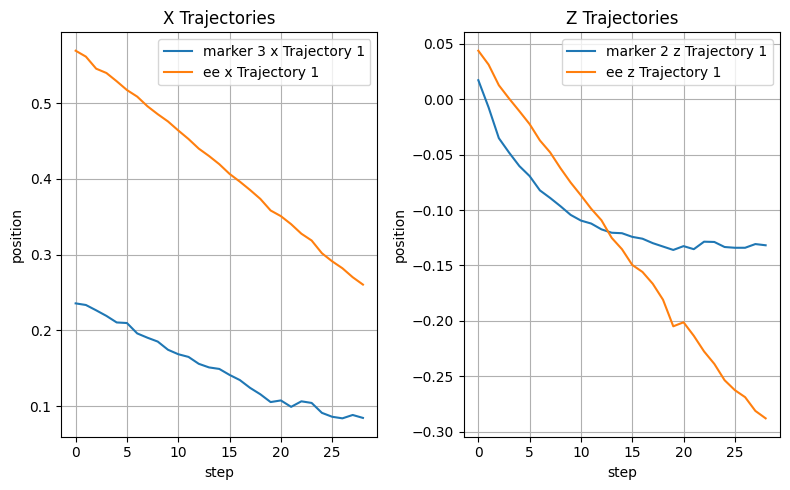

In [6]:
import matplotlib.pyplot as plt
# plot end effector and center marker trajectories for x and z directions

for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, 12], label=f"marker 3 x Trajectory {i+1}")
    plt.plot(qs[i, :, -3], label=f"ee x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, 14], label=f"marker 2 z Trajectory {i+1}")
    plt.plot(qs[i, :, -1], label=f"ee z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()